Linear Separability and Support Vectors
* Dataset: from sklearn.datasets import make_blobs
* Task: Generate a synthetic, perfectly linearly separable 2D dataset using make_blobs from sklearn.datasets.
* Action: Train a Linear SVM (kernel='linear'). Extract the coordinates of the Support Vectors from the trained model and plot the data points, highlighting the support vectors and drawing the separating hyperplane (decision boundary)


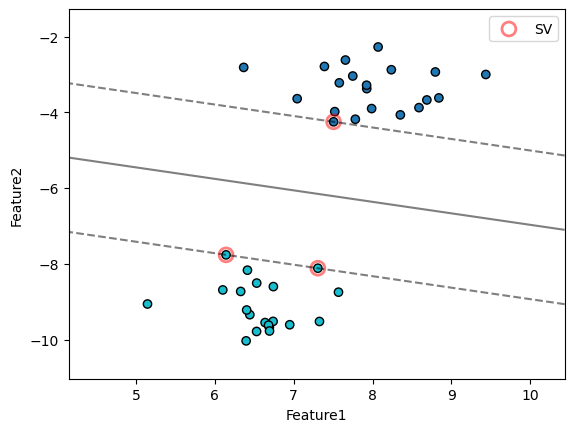

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC

X, y = make_blobs(n_samples=50, centers=2, random_state=6, cluster_std=0.60)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = SVC(kernel="linear", C=1000)
clf.fit(X_train, y_train)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="tab10", edgecolors="k")

DecisionBoundaryDisplay.from_estimator(
    clf, X_train, response_method="decision_function", plot_method="contour",
    levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"], alpha=0.5, ax=plt.gca()
)

sv = clf.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=100, linewidths=2, facecolor='none', edgecolor="r", label="SV", alpha=0.5)

plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()
plt.show()

The Kernel Trick
* Dataset: from sklearn.datasets import make_moons
* Task: Generate a non-linearly separable dataset (e.g., using make_moons or make_circles).
* Action: Train three different SVM models on this data: one with a Linear kernel, one with a Polynomial kernel, and one with an RBF (Radial Basis Function) kernel.
* Plot the decision boundaries for all three to visually demonstrate how the Kernel Trick allows SVM to solve non-linear problems.

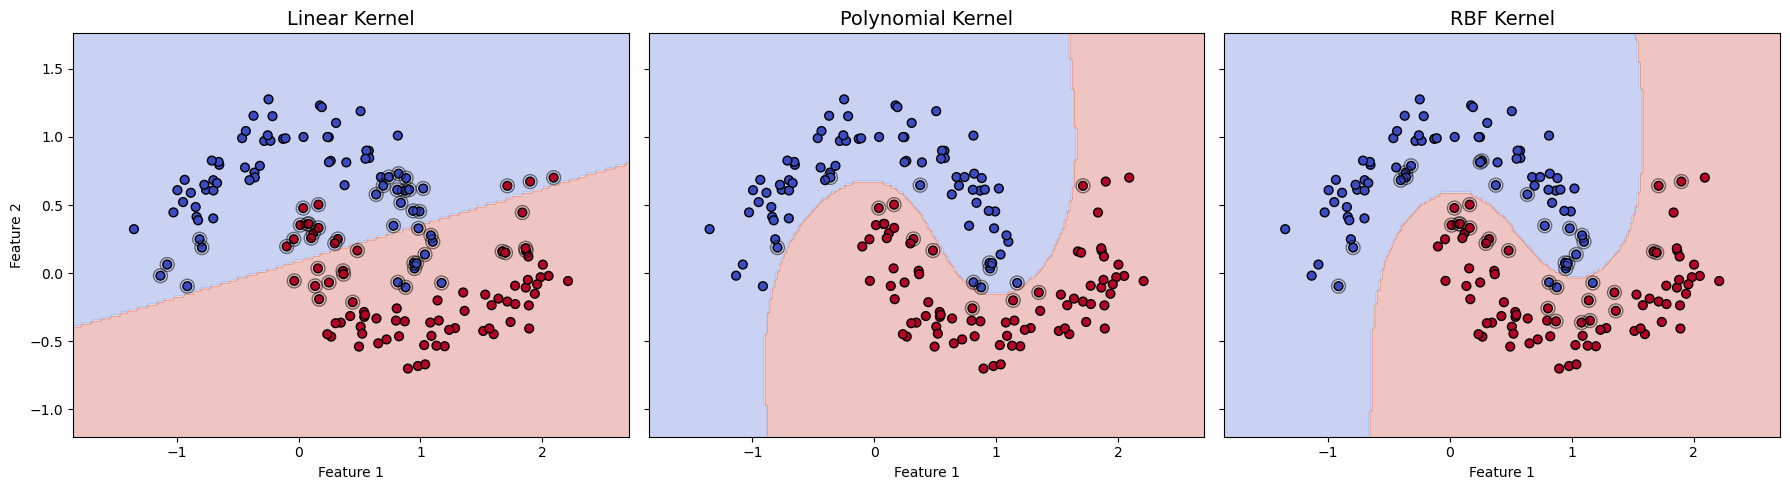

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split  # Fixed: Added missing import
from sklearn.svm import SVC

X, y = make_moons(n_samples=200, noise=0.15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Kernel": SVC(kernel="linear"),
    "Polynomial Kernel": SVC(kernel="poly", degree=3, coef0=1, C=5),
    "RBF Kernel": SVC(kernel="rbf", gamma=1, C=1)
}

x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (title, clf) in zip(axes, models.items()):
    clf.fit(X_train, y_train)
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    
    scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k', s=40)
    
    # Plot support vectors
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
               facecolors='none', edgecolors='k', alpha=0.5, label='Support Vectors')
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Feature 1")
    if title == "Linear Kernel":
        ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()